# Loading libraries

In [ ]:
# pip install gldpy

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
from itertools import combinations

from scipy.stats import shapiro, ttest_ind, mannwhitneyu, chi2_contingency, kruskal, f_oneway, levene, spearmanr, normaltest, norm

# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.experimental import enable_iterative_imputer  # required to enable
# from sklearn.impute import IterativeImputer

from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
import statsmodels.formula.api as smf

from gldpy import GLD

# Functions to analyse metadata



## Assessing data distribution

In [3]:
gld = GLD('FMKL')

def analyze_distribution_by_label(df, column, bins_hist = 20, label_col='Label', test_gof=False):
    """
    Visualize and test normality (Shapiro-Wilk) for a specific column grouped by label.

    Parameters:
    - df: DataFrame containing the data
    - column: str, name of the column to analyze
    - label_col: str, name of the label column to group by (default: 'Label')
    """
    labels = df[label_col].dropna().unique()

    print(f"\n=== Analyzing '{column}' by '{label_col}' ===\n")

    for label in labels:
        # subset = df[df[label_col] == label][column].dropna()
        # subset = subset[np.isfinite(subset)]
        subset = df.loc[df[label_col] == label, column]
        subset = pd.to_numeric(subset, errors='coerce')
        subset = subset.replace([np.inf, -np.inf], np.nan).dropna()
        print("n:", len(subset), "finite:", np.isfinite(subset).sum())
        print("min/max:", subset.min(), subset.max())
        print(f"\nLabel: {label} — Variable: {column}")
        print(f"Sample size: {len(subset)}")

        if len(subset) < 3:
            print("Not enough data for visual or Shapiro-Wilk test.")
            continue

        gld.fit_MM(subset.values, [1, 1], bins_hist = bins_hist, maxiter=1000, maxfun=1000, test_gof=test_gof )

        # Shapiro-Wilk test
        stat, p = shapiro(subset)
        print(f"Shapiro-Wilk test: W={stat:.4f}, p-value={p:.4f}")
        if p > 0.05:
            print("Probably Gaussian (normal distribution)")
        else:
            print("Probably NOT Gaussian")
        # time.sleep(5)


## Chi square

The Chi-squared test with the full $n$×2 table checks if any difference exists somewhere in the $n$ groups.

If this test is not significant, no need for pairwise tests.

If this test is significant, you know that some groups differ, but not which ones.

Chi square maths:

$O_{ij}$: observed value in row $i$, column $j$

$E_{ij}$: expected value in row $i$, column $j$


$H_0$: Sex and Label are independent. That is, the distribution of Sex is the same across all Labels.


$$E_{ij}=\frac{(Row \ total_i) \ x \ (Col \ Total_i)}{Grand \ total}$$

Being $Gran \ total$ the total number of observations.

Finally, $\chi^2$ is calculated as:


$$\chi^2 =\sum_i\sum_j\frac{O_{ij} - E_{ij}}{E_{ij}}$$

In [4]:
def chi_squared_vs_label(df, binary_col='Sex', label_col='Label'):
    """
    Perform chi-squared test of independence between a binary col and Label.

    Parameters:
    - df: DataFrame with columns for sex and label
    - binary_col: column name for binary variable (0/1)
    - label_col: column name for labels

    Returns:
    - Prints test result and contingency table
    """
    # Drop missing
    df_clean = df[[binary_col, label_col]].dropna()

    # Convert to int (if float like 0.0, 1.0)
    df_clean[binary_col] = df_clean[binary_col].astype(int)

    # Contingency table
    contingency = pd.crosstab(df_clean[label_col], df_clean[binary_col])
    contingency.columns = ['Male (0)', 'Female (1)']

    print("\nContingency Table (Label × Sex):\n")
    print(contingency)

    # Chi-squared test
    chi2, p, dof, expected = chi2_contingency(contingency)
    print("\nChi-squared Test Results:")
    print(f"Chi2 statistic = {chi2:.4f}")
    print(f"Degrees of freedom = {dof}")
    print(f"p-value = {p:.4f}\n")

    if p < 0.05:
        print("Significant association between Sex and Label")
    else:
        print("No significant association between Sex and Label")

    return contingency


## Assessing significant differences between groups

- [Kruskal Wallis](https://datatab.net/tutorial/kruskal-wallis-test)
- ANOVA

In [5]:
def test_by_label(df, column, label_col='Label', test='kruskal'):
    """
    Perform Kruskal-Wallis or ANOVA test to compare distributions across labels,
    and check assumptions for ANOVA (homoscedasticity and residuals).
    
    Parameters:
    - df: pandas DataFrame
    - column: str, numeric variable to compare
    - label_col: str, group label column (default 'Label')
    - test: str, 'kruskal' (default) or 'anova' to specify which test to perform
    """
    
    grouped = df[[label_col, column]].dropna().groupby(label_col)[column]
    data = [group for _, group in grouped]  # Extract column data per group
    labels = list(grouped.groups.keys())
    
    if len(data) < 2:
        print(f"Need at least 2 groups for {test} test.")
        return

    if test == 'kruskal':
        stat, p = kruskal(*data)
        test_name = "Kruskal-Wallis"
        print(f"\n{test_name} test for '{column}' across labels {labels}:")
        print(f"Test statistic: {stat:.4f}")
        print(f"p-value: {p:.4f}")
        if p < 0.05:
            print("Significant differences found between groups.")
        else:
            print("No significant differences between groups.")
    
    elif test == 'anova':
        formula = f'{column} ~ C({label_col})'
        model = sm.formula.ols(formula, data=df).fit()
        anova_results = sm.stats.anova_lm(model, typ=2)

        print(f"\nANOVA Table for '{column}' across labels {labels}:")
        print(anova_results)

        # Levene's test for homogeneity of variances
        lev_stat, lev_p = levene(*data)
        print("\nLevene's test for equal variances:")
        print(f"Levene statistic: {lev_stat:.4f}")
        print(f"p-value: {lev_p:.4f}")
        if lev_p < 0.05:
            print("Warning: Variances are significantly different (heteroscedasticity).")
        else:
            print("Variances are approximately equal (homoscedasticity).")

        # Residual analysis
        print("\nResidual analysis for ANOVA assumptions:")
        residuals = model.resid
        fitted = model.fittedvalues

        # Plot residuals
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        sns.histplot(residuals, kde=True, ax=axes[0])
        axes[0].set_title("Histogram of Residuals")
        axes[0].set_xlabel("Residuals")

        sm.qqplot(residuals, line='s', ax=axes[1])
        axes[1].set_title("Q-Q Plot of Residuals")

        plt.tight_layout()
        plt.show()


    else:
        raise ValueError("Invalid test specified. Choose 'kruskal' or 'anova'.")

- Mannwhitney
- [t-test](https://datatab.net/tutorial/t-test)

In [6]:
from itertools import combinations
from scipy.stats import mannwhitneyu, ttest_ind, levene
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

def cohen_d(group1, group2):
    """Compute Cohen's d for two independent samples."""
    diff = group1.mean() - group2.mean()
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1 - 1) * group1.std(ddof=1) ** 2 + (n2 - 1) * group2.std(ddof=1) ** 2) / (n1 + n2 - 2)) # doff: Delta Degrees of Freedom
    return diff / pooled_std if pooled_std != 0 else np.nan

def rank_biserial(group1, group2):
    """Compute rank biserial correlation (effect size for Mann-Whitney U)."""
    u_stat, _ = mannwhitneyu(group1, group2, alternative='two-sided')
    n1, n2 = len(group1), len(group2)
    return 1 - (2 * u_stat) / (n1 * n2)

def pairwise_test(df, label_col, column, test='mannwhitney', correction='bonferroni'):
    """
    Perform pairwise statistical tests between groups defined by label_col.

    Parameters:
    - df: pandas DataFrame
    - label_col: str, column with group labels
    - column: str, numeric variable to test
    - test: str, 'mannwhitney' (default) or 'ttest' to choose the test
    - correction: str, method for multiple testing correction (default 'bonferroni')

    Returns:
    - DataFrame with pairwise test statistics, raw and adjusted p-values,
      Levene's test p-value, and effect size.
    """

    df_clean = df[[label_col, column]].dropna()
    labels = df_clean[label_col].unique()
    pairs = list(combinations(labels, 2))

    results = []

    for a, b in pairs:
        group_a = df_clean[df_clean[label_col] == a][column]
        group_b = df_clean[df_clean[label_col] == b][column]

        stat_name = None
        stat = p = levene_p = effect_size = None

        if len(group_a) >= 3 and len(group_b) >= 3:
            # Levene's test for variance homogeneity
            _, levene_p = levene(group_a, group_b)

            if test == 'mannwhitney':
                stat, p = mannwhitneyu(group_a, group_b, alternative='two-sided')
                stat_name = 'U'
                effect_size = rank_biserial(group_a, group_b)
            elif test == 'ttest':
                if levene_p < 0.05:
                    # If variances are unequal, use Welch's t-test
                    stat, p = ttest_ind(group_a, group_b, equal_var=False)
                else:
                    stat, p = ttest_ind(group_a, group_b, equal_var=True) 
                stat_name = 't'
                effect_size = cohen_d(group_a, group_b)
            else:
                raise ValueError("Invalid test specified. Choose 'mannwhitney' or 'ttest'.")

        results.append({
            'Group1': a,
            'Group2': b,
            stat_name: stat,
            'p_raw': p,
            'p_levene': levene_p,
            'effect_size': effect_size
        })

    results_df = pd.DataFrame(results)

    valid_methods = ['bonferroni', 'holm', 'fdr_bh', 'fdr_by', 'sidak', 'holm-sidak', 'hommel']
    if correction not in valid_methods:
        raise ValueError(f"Unsupported correction method: {correction}")

    pvals = results_df['p_raw'].fillna(1.0).values
    _, p_adjusted, _, _ = multipletests(pvals, method=correction)
    results_df['p_adjusted'] = p_adjusted.clip(max=1.0)

    return results_df


# Loading metadata

In [7]:
df = pd.read_csv('./data/HUMV_enhanced_metadata.csv', sep = ',')
df.head()

,ID,Sex,Age,Label,UPDRS_III_2024,H&Y_2024,Years_education
0,HUMV_HC_1,1,67,0,0.0,0.0,15.0
1,HUMV_HC_2,1,65,0,1.0,0.0,17.0
2,HUMV_HC_3,1,69,0,NaN,NaN,NaN
3,HUMV_HC_4,1,39,0,0.0,0.0,8.0
4,HUMV_HC_5,1,67,0,1.0,0.0,10.0


# Metadata analysis with 3 groups (HC + NFC, AC, PD)

In [8]:
# Replace labels 1 with 0
df_3_groups = df.copy()
df_3_groups['Label'] = df_3_groups['Label'].replace({1: 0})

# no DaTSCAN: ['HUMV_AC_2','HUMV_AC_5', 'HUMV_AC_7','HUMV_AC_8','HUMV_AC_13','HUMV_AC_14','HUMV_AC_15', 'HUMV_AC_16', 'HUMV_AC_26','HUMV_AC_27','HUMV_AC_28','HUMV_AC_29', 'HUMV_AC_31']
# negative datscan: "HUMV_AC_1", "HUMV_AC_3", "HUMV_AC_25", "HUMV_AC_33"


# Now labels 0 and 1 are merged into 0
print(df_3_groups['Label'].value_counts())

Label
0    50
2    34
3    34
Name: count, dtype: int64


In [9]:
# List of patient IDs to remove
# patients_to_remove = ['HUMV_HC_4', 'HUMV_HC_9', 'HUMV_HC_25', 'HUMV_NFC_1', 'HUMV_NFC_11' ,'HUMV_PD_1', 'HUMV_PD_2', 'HUMV_PD_9', 'HUMV_PD_13', 'HUMV_AC_2','HUMV_AC_5', 'HUMV_AC_7','HUMV_AC_8','HUMV_AC_13','HUMV_AC_14','HUMV_AC_15', 'HUMV_AC_16', 'HUMV_AC_24', 'HUMV_AC_26','HUMV_AC_27','HUMV_AC_28','HUMV_AC_29', 'HUMV_AC_31', 'HUMV_AC_32'] # 'HUMV_AC_24','HUMV_AC_32','HUMV_AC_2', 'HUMV_AC_5', 'HUMV_AC_8','HUMV_AC_29'

#patients_to_remove = ['HUMV_HC_4', 'HUMV_AC_2', 'HUMV_AC_5', 'HUMV_AC_8','HUMV_AC_29','HUMV_PD_1', 'HUMV_PD_2'] # DisVoice Study

#patients_to_remove = ['HUMV_HC_3','HUMV_HC_4', 'HUMV_HC_7','HUMV_NFC_2', 'HUMV_NFC_3', 'HUMV_NFC_5','HUMV_NFC_8','HUMV_NFC_9','HUMV_NFC_10','HUMV_NFC_11', 'HUMV_NFC_12', 'HUMV_NFC_13', 'HUMV_NFC_14', 'HUMV_NFC_23', 'HUMV_NFC_24'] # DisVoice Study

# patients_to_remove = ['HUMV_HC_1','HUMV_HC_3','HUMV_HC_4', 'HUMV_HC_5','HUMV_HC_6','HUMV_HC_7', 'HUMV_HC_8', 'HUMV_HC_9', 'HUMV_HC_11', 'HUMV_HC_13','HUMV_HC_14','HUMV_HC_15', 'HUMV_HC_16', 'HUMV_HC_17','HUMV_HC_20', 'HUMV_HC_24','HUMV_HC_25', 'HUMV_HC_26', 'HUMV_NFC_1', 'HUMV_NFC_3', 'HUMV_NFC_4', 'HUMV_NFC_6','HUMV_NFC_10','HUMV_NFC_11', 'HUMV_NFC_12', 'HUMV_NFC_13', 'HUMV_NFC_15', 'HUMV_NFC_17', 'HUMV_NFC_23', 'HUMV_NFC_24', 'HUMV_AC_2','HUMV_AC_5', 'HUMV_AC_7','HUMV_AC_8','HUMV_AC_13','HUMV_AC_14','HUMV_AC_15', 'HUMV_AC_16', 'HUMV_AC_26','HUMV_AC_27','HUMV_AC_28','HUMV_AC_29', 'HUMV_AC_31', "HUMV_AC_1", "HUMV_AC_3", "HUMV_AC_25", "HUMV_AC_33"] # Eliminando AC sin DaTSCAN y negativos y DatSCAN negativos

# patients_to_remove_TFM = ['HUMV_HC_1','HUMV_HC_3','HUMV_HC_4', 'HUMV_HC_5','HUMV_HC_6','HUMV_HC_7', 'HUMV_HC_8', 'HUMV_HC_9', 'HUMV_HC_11', 'HUMV_HC_13','HUMV_HC_14','HUMV_HC_15', 'HUMV_HC_16', 'HUMV_HC_17','HUMV_HC_20', 'HUMV_HC_24','HUMV_HC_25', 'HUMV_HC_26', 'HUMV_NFC_1', 'HUMV_NFC_3', 'HUMV_NFC_4', 'HUMV_NFC_6','HUMV_NFC_10','HUMV_NFC_11', 'HUMV_NFC_12', 'HUMV_NFC_13', 'HUMV_NFC_15', 'HUMV_NFC_17', 'HUMV_NFC_23', 'HUMV_NFC_24'] # Eliminando AC sin DaTSCAN y negativos y DatSCAN negativos

patients_to_remove_TFM = ["HUMV_NFC_11","HUMV_HC_25","HUMV_HC_9","HUMV_NFC_1","HUMV_NFC_17","HUMV_HC_15","HUMV_NFC_10","HUMV_NFC_23","HUMV_NFC_5","HUMV_NFC_24","HUMV_HC_4", "HUMV_NFC_21", "HUMV_NFC_16", "HUMV_HC_18", "HUMV_PD_1", "HUMV_PD_2", "HUMV_PD_9", "HUMV_PD_13", "HUMV_AC_2", "HUMV_AC_5", "HUMV_AC_32", "HUMV_AC_24", "HUMV_AC_14"] 


# no DaTSCAN: ['HUMV_AC_2','HUMV_AC_5', 'HUMV_AC_7','HUMV_AC_8','HUMV_AC_13','HUMV_AC_14','HUMV_AC_15', 'HUMV_AC_16', 'HUMV_AC_26','HUMV_AC_27','HUMV_AC_28','HUMV_AC_29', 'HUMV_AC_31']


# Remove duplicates just in case
patients_to_remove = list(set(patients_to_remove_TFM))

# Filter the dataframe
df_3_groups = df_3_groups[~df_3_groups['ID'].isin(patients_to_remove_TFM)].copy()

       count       mean       std   min    25%   50%    75%   max
Label                                                            
0       36.0  67.083333  6.716185  53.0  62.75  66.5  72.50  79.0
2       29.0  63.724138  8.915863  51.0  57.00  63.0  68.00  82.0
3       30.0  67.233333  8.946906  49.0  62.25  67.0  74.75  82.0


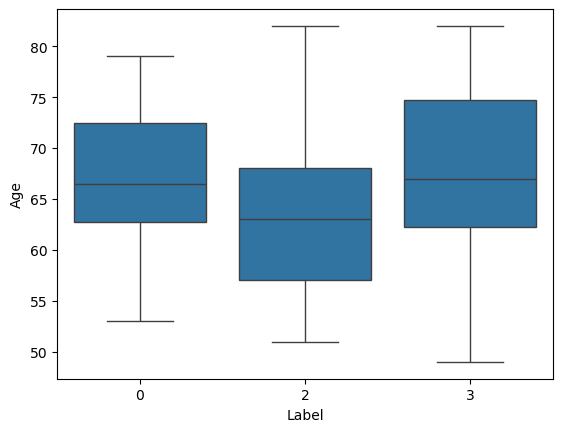

In [10]:
# Summary stats
print(df_3_groups.groupby('Label')['Age'].describe())

# Boxplot
sns.boxplot(data=df_3_groups, x='Label', y='Age')
plt.show()

## Checking distribution of data

### Age


=== Analyzing 'Age' by 'Label' ===

n: 36 finite: 36
min/max: 53 79

Label: 0 — Variable: Age
Sample size: 36
Optimization terminated successfully.
         Current function value: 0.000047
         Iterations: 46
         Function evaluations: 89

Sample moments:  (np.float64(67.08333333333333), np.float64(43.85416666666666), np.float64(-0.034023206788140165), np.float64(2.2597864677661117))
Fitted moments:  (np.float64(67.08333333333333), np.float64(43.85416666666666), np.float64(-0.03405474480468009), np.float64(2.2598329953153145))

Parameters:  [np.float64(67.16844932505617), np.float64(0.16148011250635452), np.float64(0.36084417698945165), np.float64(0.38678280825487193)]
Shapiro-Wilk test: W=0.9746, p-value=0.5631
Probably Gaussian (normal distribution)
n: 29 finite: 29
min/max: 51 82

Label: 2 — Variable: Age
Sample size: 29
Optimization terminated successfully.
         Current function value: 0.000005
         Iterations: 38
         Function evaluations: 73

Sample moments:

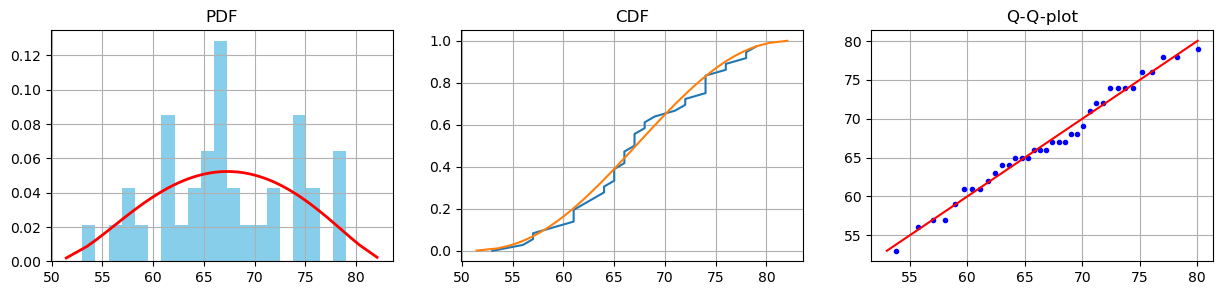

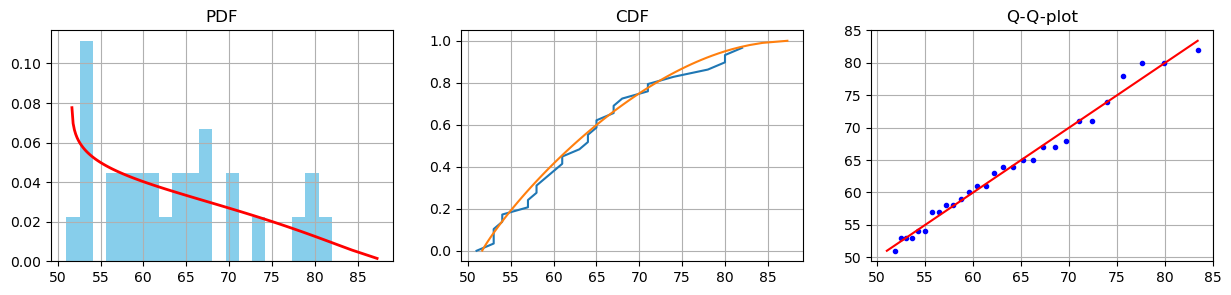

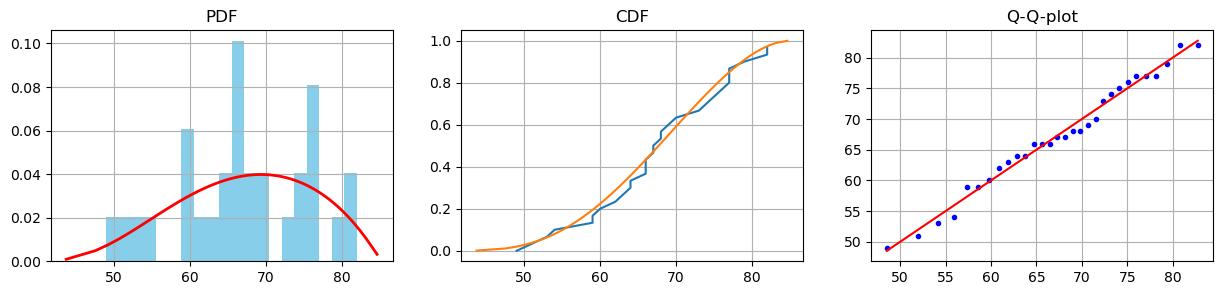

In [11]:
# Example usage:
analyze_distribution_by_label(df_3_groups, column='Age', bins_hist = 20, test_gof=False)

**GLD results analysis example**:

Age Label 0:

**Current function value: 0.000069** -> GLD parameter estimation converged successfully, with minimal error, after 58 iterations

**Function evaluations: 111** -> The fitting algorithm tried 111 function evaluations to match your data's moments with the theoretical GLD's moments.

**Fitted GLD Parameters: [67.555, 0.1434, 0.2235, 0.2175]**

This correspond to:

$\lambda_1$ = 67.56 (location, center)

$\lambda_2$ = 0.1434 (scale)

$\lambda_3$ = 0.2235 (left tail shape)

$\lambda_4$ = 0.2175 (right tail shape)


**statistic = 0.107**
**p-value = 0.605**

Null hypothesis: the data comes from the fitted distribution.

p > 0.05 → we fail to reject the null hypothesis → the GLD fits the data well.

A low KS statistic (0.107) indicates low maximum deviation between the empirical and fitted CDF.

**Chi²-like statistic = 9.33
p-value = 0.23**

Also non-significant (p > 0.05):

The histogram-based test finds no evidence that the GLD is a poor fit.

Confirms the result from the KS test.


### Years education


=== Analyzing 'Years_education' by 'Label' ===

n: 35 finite: 35
min/max: 8.0 22.0

Label: 0 — Variable: Years_education
Sample size: 35
Optimization terminated successfully.
         Current function value: 0.045290
         Iterations: 95
         Function evaluations: 177

Sample moments:  (np.float64(12.914285714285715), np.float64(19.792653061224485), np.float64(0.47345383471585656), np.float64(2.0119832408238723))
Fitted moments:  (np.float64(12.914285714285715), np.float64(19.792653061224485), np.float64(0.4281636276002734), np.float64(2.0572734483405384))

Parameters:  [np.float64(10.501949553282419), np.float64(0.11507066993537308), np.float64(2.2144756438731337), np.float64(0.6987103832832213)]
Shapiro-Wilk test: W=0.8938, p-value=0.0027
Probably NOT Gaussian
n: 29 finite: 29
min/max: 4.0 22.0

Label: 2 — Variable: Years_education
Sample size: 29
Optimization terminated successfully.
         Current function value: 0.000014
         Iterations: 65
         Function evaluati

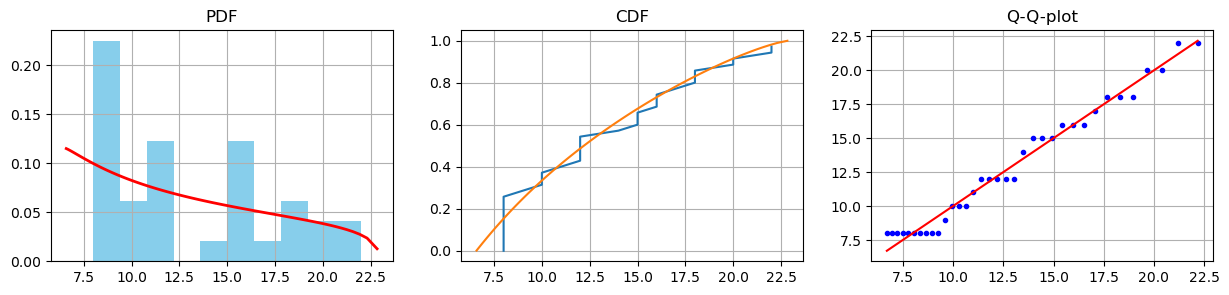

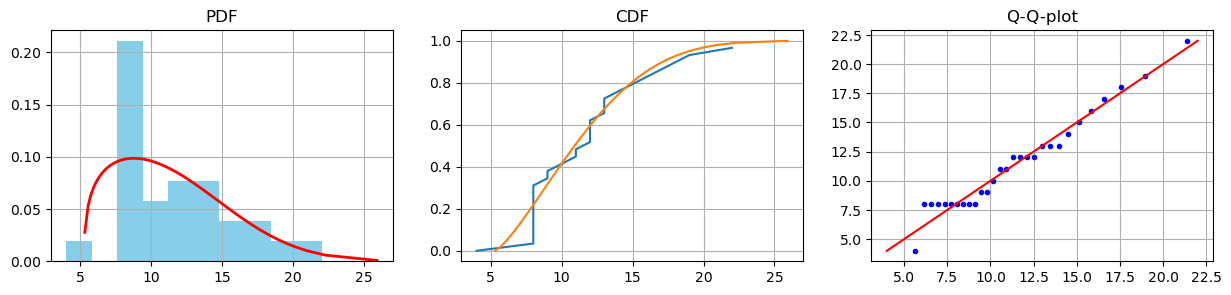

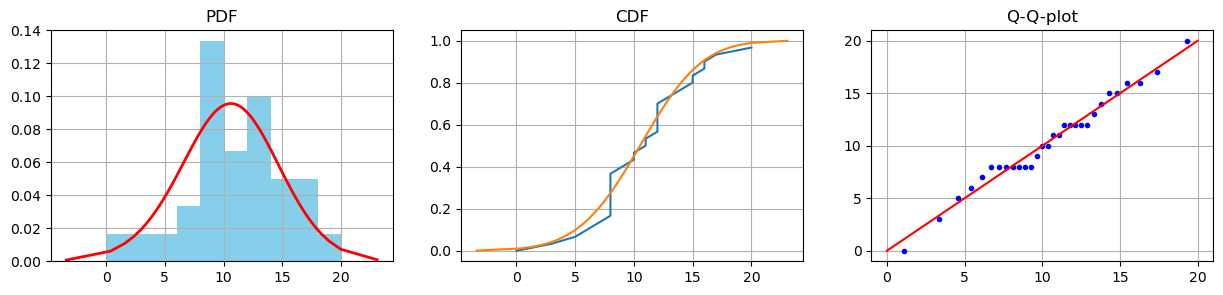

In [12]:
analyze_distribution_by_label(df_3_groups, column='Years_education', bins_hist= 10, test_gof=False )

## UPDRS


=== Analyzing 'UPDRS_III_2024' by 'Label' ===

n: 35 finite: 35
min/max: 0.0 4.0

Label: 0 — Variable: UPDRS_III_2024
Sample size: 35
Optimization terminated successfully.
         Current function value: 0.041238
         Iterations: 81
         Function evaluations: 149

Sample moments:  (np.float64(1.2285714285714286), np.float64(1.433469387755102), np.float64(0.45245897554163017), np.float64(1.9929042501855019))
Fitted moments:  (np.float64(1.2285714285714286), np.float64(1.433469387755102), np.float64(0.411220943906417), np.float64(2.034142287353031))

Parameters:  [np.float64(0.5942213719305496), np.float64(0.42294330437437694), np.float64(2.187488190515215), np.float64(0.718151766988639)]
Shapiro-Wilk test: W=0.8462, p-value=0.0002
Probably NOT Gaussian
n: 29 finite: 29
min/max: 0.0 7.0

Label: 2 — Variable: UPDRS_III_2024
Sample size: 29
Optimization terminated successfully.
         Current function value: 0.057052
         Iterations: 167
         Function evaluations: 297



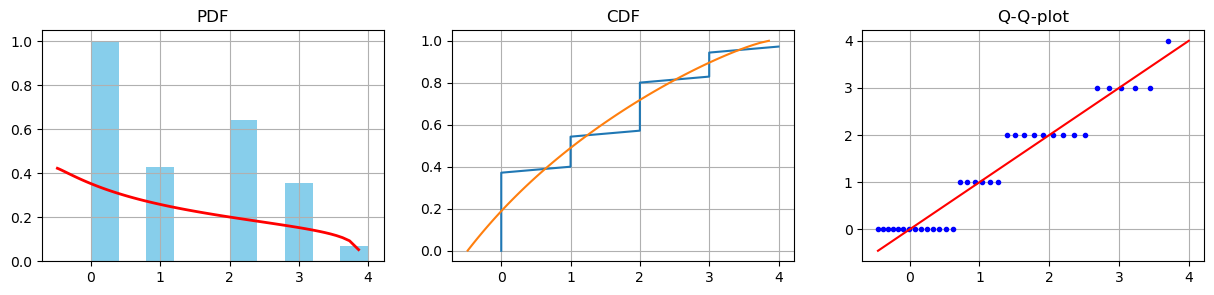

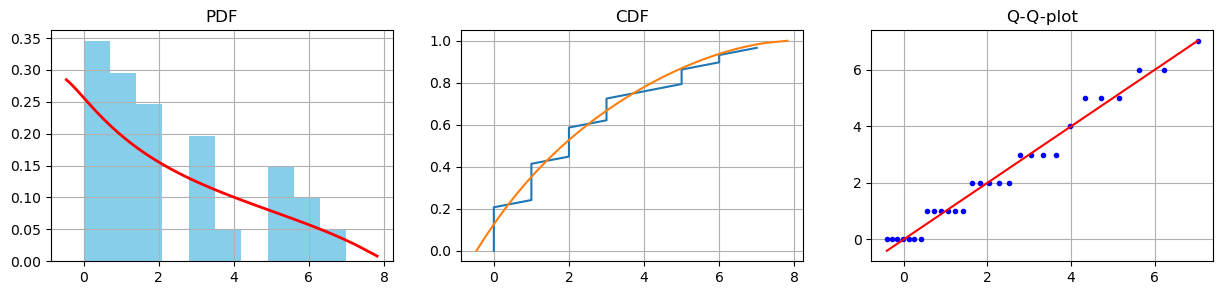

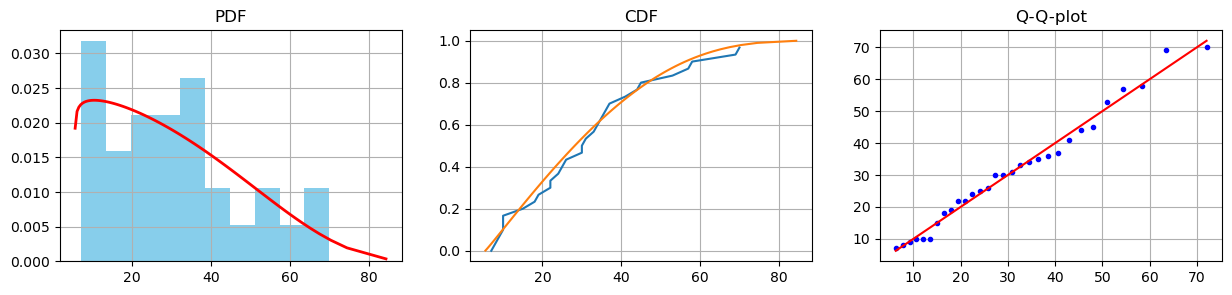

In [24]:
analyze_distribution_by_label(df_3_groups, column='UPDRS_III_2024', bins_hist= 10, test_gof=False )

## Statistical test

### Sex

In [13]:
sex_contigency_filtered_data = chi_squared_vs_label(df_3_groups)


Contingency Table (Label × Sex):

       Male (0)  Female (1)
Label                      
0            13          23
2            11          18
3             9          21

Chi-squared Test Results:
Chi2 statistic = 0.4574
Degrees of freedom = 2
p-value = 0.7956

No significant association between Sex and Label


In [ ]:
df_HC_vs_PD = df_3_groups[df_3_groups['Label'].isin([0, 3])]
sex_contigency_filtered_data_HC_vs_PD = chi_squared_vs_label(df_HC_vs_PD)


Contingency Table (Label × Sex):

       Male (0)  Female (1)
Label                      
0            13          23
3             9          21

Chi-squared Test Results:
Chi2 statistic = 0.0688
Degrees of freedom = 1
p-value = 0.7932

No significant association between Sex and Label


In [21]:
df_AC_vs_PD = df_3_groups[df_3_groups['Label'].isin([2, 3])]
sex_contigency_filtered_data_AC_vs_PD = chi_squared_vs_label(df_AC_vs_PD)


Contingency Table (Label × Sex):

       Male (0)  Female (1)
Label                      
2            11          18
3             9          21

Chi-squared Test Results:
Chi2 statistic = 0.1357
Degrees of freedom = 1
p-value = 0.7126

No significant association between Sex and Label


In [22]:
df_HC_vs_AC = df_3_groups[df_3_groups['Label'].isin([0, 2])]
sex_contigency_filtered_data_HC_vs_AC = chi_squared_vs_label(df_HC_vs_AC)


Contingency Table (Label × Sex):

       Male (0)  Female (1)
Label                      
0            13          23
2            11          18

Chi-squared Test Results:
Chi2 statistic = 0.0000
Degrees of freedom = 1
p-value = 1.0000

No significant association between Sex and Label


### Age


ANOVA Table for 'Age' across labels [0, 2, 3]:
               sum_sq    df         F    PR(>F)
C(Label)   237.037598   2.0  1.779936  0.174407
Residual  6125.909770  92.0       NaN       NaN

Levene's test for equal variances:
Levene statistic: 1.4188
p-value: 0.2472
Variances are approximately equal (homoscedasticity).

Residual analysis for ANOVA assumptions:


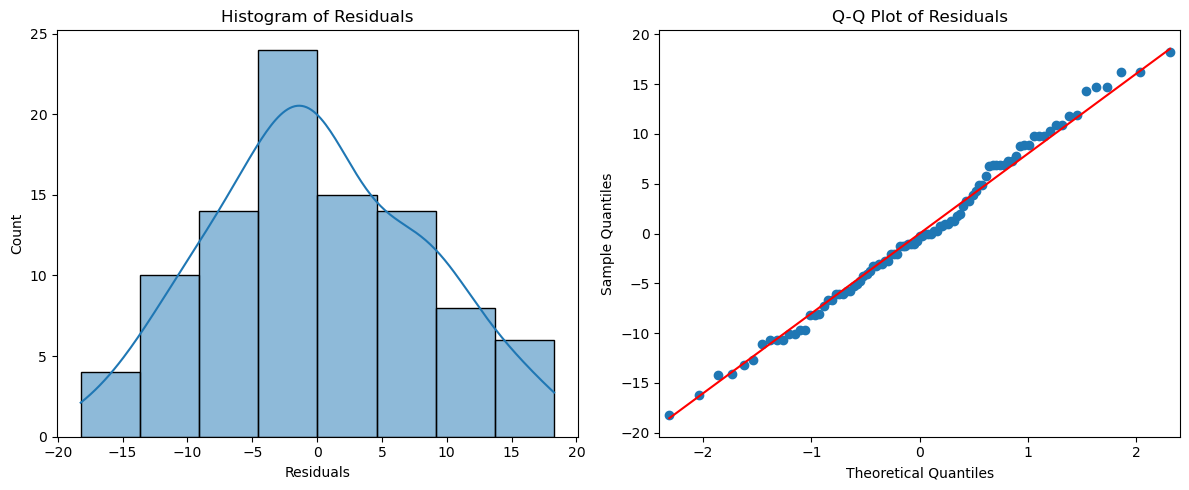

In [14]:
# test_by_label(df_3_groups, column='Age', label_col='Label', test = 'kruskal')
test_by_label(df_3_groups, column='Age', label_col='Label', test = 'anova')

In [15]:
result = pairwise_test(df_3_groups, label_col = 'Label', column='Age', test='ttest', correction='fdr_bh')
print(result)

   Group1  Group2         t     p_raw  p_levene  effect_size  p_adjusted
0       0       2  1.732399  0.088096  0.124759     0.432269    0.205341
1       0       3 -0.077729  0.938286  0.152289    -0.019215    0.938286
2       2       3 -1.508719  0.136894  0.939880    -0.392894    0.205341


### Years of education

In [16]:
test_by_label(df_3_groups, column='Years_education', label_col='Label', test = 'kruskal')


Kruskal-Wallis test for 'Years_education' across labels [0, 2, 3]:
Test statistic: 3.6995
p-value: 0.1573
No significant differences between groups.


In [18]:
result = pairwise_test(df_3_groups, label_col = 'Label', column='Years_education', test='mannwhitney', correction='fdr_bh')
print(result)

   Group1  Group2      U     p_raw  p_levene  effect_size  p_adjusted
0       0       2  587.0  0.279298  0.380067    -0.156650    0.418947
1       0       3  667.0  0.059580  0.563755    -0.270476    0.178740
2       2       3  487.0  0.429188  0.771911    -0.119540    0.429188


## UPDRS

In [25]:
test_by_label(df_3_groups, column='UPDRS_III_2024', label_col='Label', test = 'kruskal')


Kruskal-Wallis test for 'UPDRS_III_2024' across labels [0, 2, 3]:
Test statistic: 63.2567
p-value: 0.0000
Significant differences found between groups.


In [26]:
result = pairwise_test(df_3_groups, label_col = 'Label', column='UPDRS_III_2024', test='mannwhitney', correction='fdr_bh')
print(result)

   Group1  Group2      U         p_raw      p_levene  effect_size  \
0       0       2  371.0  5.917422e-02  1.488649e-02     0.268966   
1       0       3    0.0  3.642969e-12  1.448293e-09     1.000000   
2       2       3    0.5  4.306899e-11  1.010110e-07     0.998851   

     p_adjusted  
0  5.917422e-02  
1  1.092891e-11  
2  6.460349e-11  
